## Loading O*NET Database

From the O*NET Resource Center website, 45 files that comprise the O*NET 30.3 Database were downloaded onto the local machine. They will each need to be loaded as pandas dataframe objects in order to be examined.

### Loading libraries

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_onet_files(data_dir: str) -> dict[str, pd.DataFrame]:
    data_dir = Path(data_dir)
    tables = {}
    for path in data_dir.glob("*.txt"):
        name = path.stem
        tables[name] = pd.read_csv(path, sep="\t", dtype=str, low_memory=False)
    return tables

tables = load_onet_files("C:/Users/patel/Python/db_30_3_text")

In [3]:
tables["Knowledge"].head(10)

,O*NET-SOC Code,Element ID,Element Name,Scale ID,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source
0,11-1011.00,2.C.1.a,Administration and Management,IM,4.78,28,0.1102,4.5564,5.0000,N,NaN,08/2023,Incumbent
1,11-1011.00,2.C.1.a,Administration and Management,LV,6.50,28,0.2130,6.0666,6.9409,N,N,08/2023,Incumbent
2,11-1011.00,2.C.1.b,Administrative,IM,2.42,28,0.4651,1.4662,3.3749,N,NaN,08/2023,Incumbent
3,11-1011.00,2.C.1.b,Administrative,LV,2.69,28,0.8678,0.9078,4.4690,N,N,08/2023,Incumbent
4,11-1011.00,2.C.1.c,Economics and Accounting,IM,4.04,28,0.3480,3.3246,4.7526,N,NaN,08/2023,Incumbent
5,11-1011.00,2.C.1.c,Economics and Accounting,LV,4.98,28,0.6849,3.5754,6.3861,N,N,08/2023,Incumbent
6,11-1011.00,2.C.1.d,Sales and Marketing,IM,3.81,28,0.4018,2.9881,4.6368,N,NaN,08/2023,Incumbent
7,11-1011.00,2.C.1.d,Sales and Marketing,LV,5.04,28,0.6803,3.6445,6.4364,N,N,08/2023,Incumbent
8,11-1011.00,2.C.1.e,Customer and Personal Service,IM,4.39,28,0.3139,3.7507,5.0000,N,NaN,08/2023,Incumbent
9,11-1011.00,2.C.1.e,Customer and Personal Service,LV,5.94,28,0.5822,4.7494,7.0000,N,N,08/2023,Incumbent


### Missing Values

Next, missing values and duplicates will be analyzed prior to pre-processing steps.

In [4]:
def missing_values_report(tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for name, df in tables.items():
        n_rows = len(df)
        for col in df.columns:
            n_missing = df[col].isna().sum()
            if n_missing > 0:
                rows.append({
                    "table": name,
                    "column": col,
                    "n_missing": n_missing,
                    "pct_missing": round(n_missing / n_rows * 100, 2),
                    "n_rows": n_rows,
                })
    return pd.DataFrame(rows).sort_values(["table", "pct_missing"], ascending=[True, False])

report = missing_values_report(tables)
report


,table,column,n_missing,pct_missing,n_rows
0,Abilities,Not Relevant,46488,50.00,92976
1,Content Model Reference,Description,2419,80.47,3006
4,Education,Lower CI Bound,7477,67.36,11100
5,Education,Upper CI Bound,7477,67.36,11100
3,Education,Standard Error,2720,24.50,11100
6,Education,Recommend Suppress,2720,24.50,11100
2,Education,Category,564,5.08,11100
7,Emerging Tasks,Original Task ID,275,83.84,328
8,Emerging Tasks,Original Task,275,83.84,328
9,Essential Skills,Not Relevant,8940,50.00,17880


### Summary Statistics (Numerical Columns)

In [5]:
NUMERIC_COLUMNS = {
   "Data Value", "N", "Standard Error", "Lower CI Bound", "Upper CI Bound",
    "Percent", "Anchor Value", "Minimum", "Maximum", "Index", "Job Zone",
    "Incumbents Responding",
}

for name, df in tables.items():
    for col in df.columns:
        if col in NUMERIC_COLUMNS:
            df[col] = pd.to_numeric(df[col], errors="coerce")


def numeric_summary(tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    frames = []
    for name, df in tables.items():
        cols = [c for c in df.columns if c in NUMERIC_COLUMNS]
        if not cols:
            continue
        numeric_df = df[cols].apply(pd.to_numeric, errors="coerce")
        desc = numeric_df.describe().T
        desc.insert(0, "table", name)
        frames.append(desc)
    return pd.concat(frames).rename_axis("column").reset_index()

numeric_summary_df = numeric_summary(tables)

numeric_summary_df

,column,table,count,mean,std,min,25%,50%,75%,max
0,Data Value,Abilities,92976.0,2.342469,1.145188,0.0000,1.620000,2.50000,3.120000,6.0000
1,N,Abilities,92976.0,8.000000,0.000000,8.0000,8.000000,8.00000,8.000000,8.0000
2,Standard Error,Abilities,92976.0,0.131183,0.096018,0.0000,0.000000,0.16370,0.183000,0.7425
3,Lower CI Bound,Abilities,92976.0,2.089959,1.125112,0.0000,1.129600,2.12960,2.929200,6.0000
4,Upper CI Bound,Abilities,92976.0,2.599623,1.188169,0.0000,2.000000,2.87040,3.370000,6.1200
5,Data Value,Career Interest Types,8307.0,3.251729,2.006369,0.0000,1.440000,3.00000,5.000000,7.0000
6,Data Value,Education,11100.0,8.054315,16.779963,0.0000,0.000000,0.00000,6.922500,100.0000
7,N,Education,11100.0,25.202973,9.493724,9.0000,20.000000,23.00000,28.000000,98.0000
8,Standard Error,Education,8380.0,3.143625,5.138177,0.0000,0.000000,0.00000,5.489000,28.3134
9,Lower CI Bound,Education,3623.0,8.026174,12.809995,0.0017,0.721200,2.25970,9.266850,88.5275


### Summary Statistics (Categorical Columns)

In [6]:
def categorical_summary(tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for name, df in tables.items():
        for col in df.columns:
            if col in NUMERIC_COLUMNS:
                continue
            rows.append({
                "table": name,
                "column": col,
                "n_unique": df[col].nunique(dropna=True),
                "top_value": df[col].mode().iloc[0] if not df[col].mode().empty else None,
            })
    return pd.DataFrame(rows)

categorical_summary_df = categorical_summary(tables)

categorical_summary_df

,table,column,n_unique,top_value
0,Abilities to Work Activities,Abilities Element ID,50,1.A.1.b.4
1,Abilities to Work Activities,Abilities Element Name,50,Deductive Reasoning
2,Abilities to Work Activities,Work Activities Element ID,41,4.A.3.a.4
3,Abilities to Work Activities,Work Activities Element Name,41,"Operating Vehicles, Mechanized Devices, or Equ..."
4,Abilities to Work Context,Abilities Element ID,33,1.A.1.b.3
...,...,...,...,...
222,Work Styles,Element ID,21,1.D.1.a
223,Work Styles,Element Name,21,Achievement Orientation
224,Work Styles,Scale ID,2,DR
225,Work Styles,Date,1,12/2025


## Visualizations

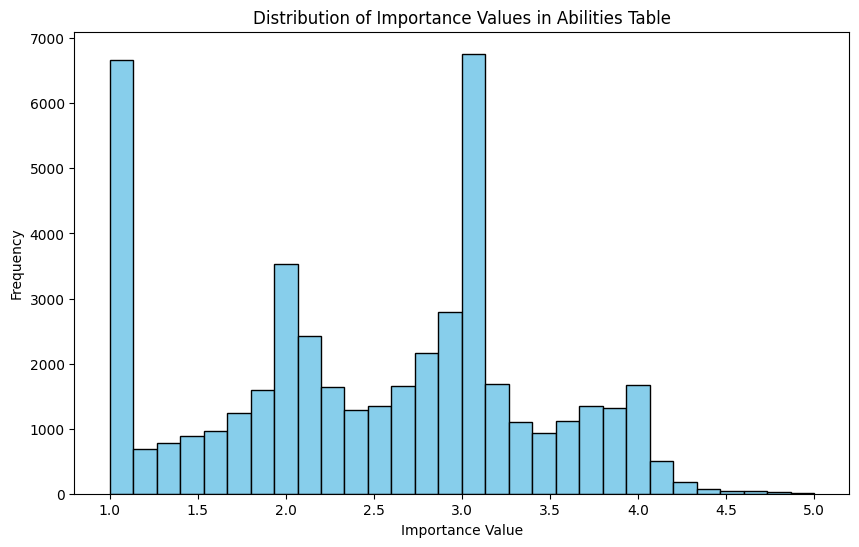

In [7]:
abilities = tables["Abilities"].assign(
    **{"Data_Value": pd.to_numeric(tables["Abilities"]["Data Value"], errors="coerce")}
)
importance = abilities[abilities["Scale ID"] == "IM"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(importance["Data_Value"].dropna(), bins=30, color="skyblue", edgecolor="black")
ax.set_xlabel("Importance Value")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Importance Values in Abilities Table")
plt.show()

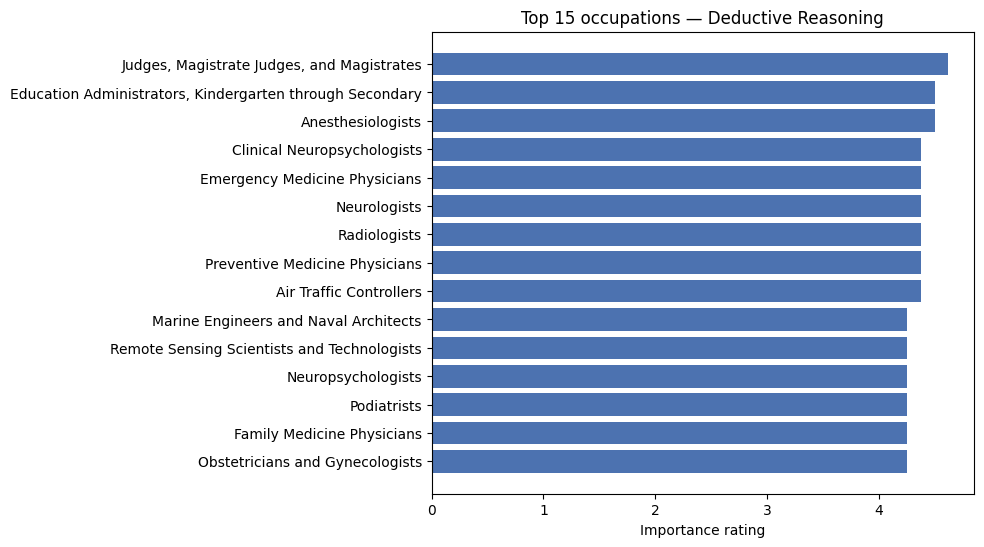

In [8]:
top15 = (
    importance[importance["Element Name"] == "Deductive Reasoning"]
    .nlargest(15, "Data Value")
    .merge(tables["Occupation Data"][["O*NET-SOC Code", "Title"]], on="O*NET-SOC Code")
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top15["Title"], top15["Data Value"], color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Importance rating")
ax.set_title("Top 15 occupations — Deductive Reasoning")
plt.show()

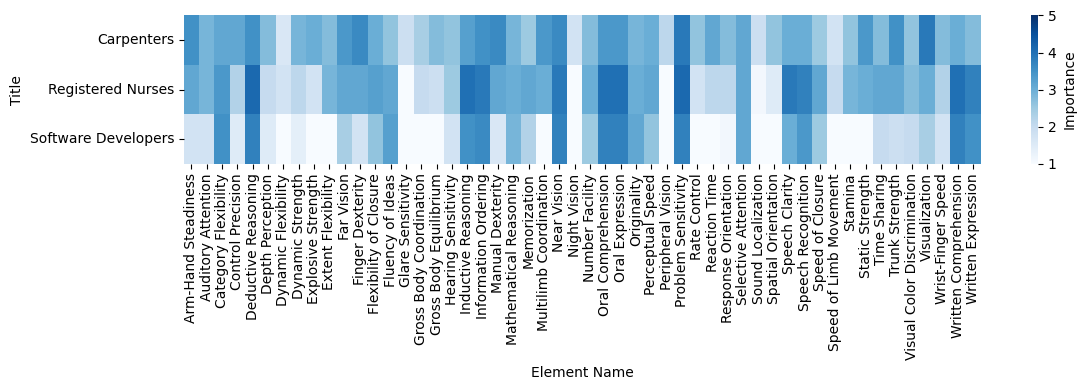

In [9]:
sample_titles = ["Software Developers", "Registered Nurses", "Carpenters", "Accountants"]
occ_codes = tables["Occupation Data"].query("Title in @sample_titles")

profile = (
    importance.merge(occ_codes, on="O*NET-SOC Code")
    .pivot_table(index="Title", columns="Element Name", values="Data Value")
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(profile, cmap="Blues", vmin=1, vmax=5, cbar_kws={"label": "Importance"}, ax=ax)
plt.tight_layout()
plt.show()

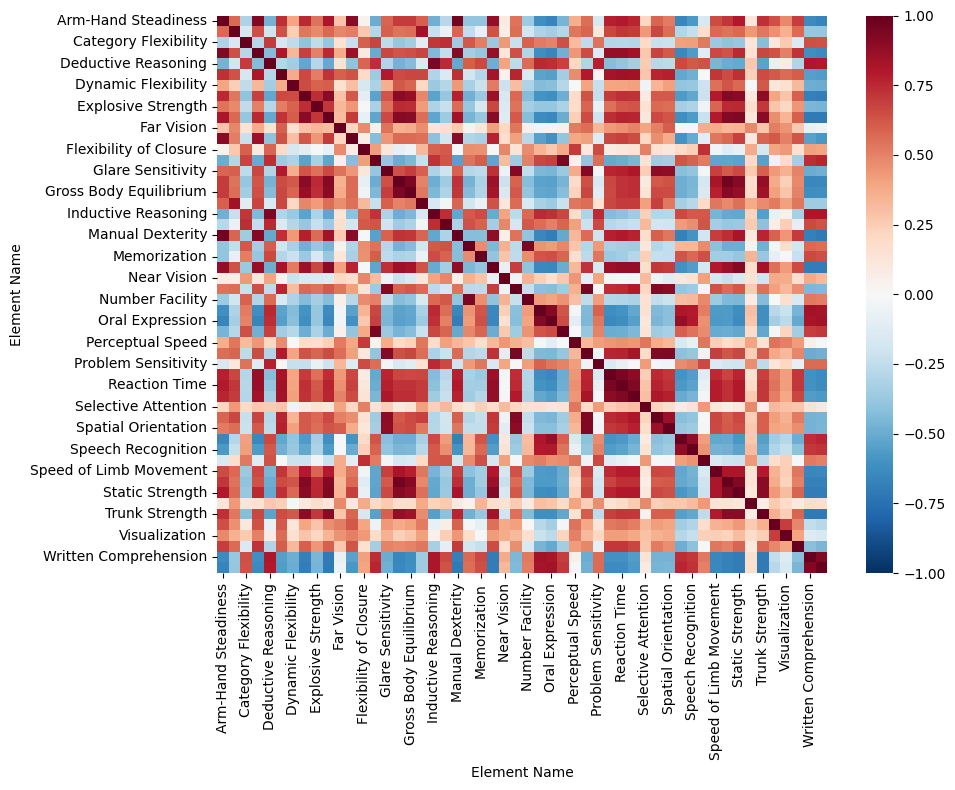

In [10]:
wide = importance.pivot_table(index="O*NET-SOC Code", columns="Element Name", values="Data Value")
corr = wide.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
plt.tight_layout()
plt.show()

## Data Quality & Relationship Analysis

Additional checks to support the EDA write-up: duplicate keys, scale-bound validation,
redundancy between the Importance/Level scales, category balance, and how ability
importance relates to Job Zone (occupation preparation level).

### Duplicate Checks

In [11]:
print("Occupation Data duplicated SOC codes:",
      tables["Occupation Data"]["O*NET-SOC Code"].duplicated().sum(), "/", len(tables["Occupation Data"]))

key = ["O*NET-SOC Code", "Element ID", "Scale ID"]
print("Abilities duplicated (SOC, Element, Scale) keys:",
      tables["Abilities"].duplicated(subset=key).sum(), "/", len(tables["Abilities"]))
print("Knowledge duplicated (SOC, Element, Scale) keys:",
      tables["Knowledge"].duplicated(subset=key).sum(), "/", len(tables["Knowledge"]))
print("Job Zones duplicated SOC codes:",
      tables["Job Zones"].duplicated(subset=["O*NET-SOC Code"]).sum(), "/", len(tables["Job Zones"]))

Occupation Data duplicated SOC codes: 0 / 1016
Abilities duplicated (SOC, Element, Scale) keys: 0 / 92976
Knowledge duplicated (SOC, Element, Scale) keys: 0 / 59004
Job Zones duplicated SOC codes: 0 / 923


### Scale Bound Violations

Checks whether any `Data Value` falls outside the documented `Minimum`/`Maximum` for its
`Scale ID` in `Scales Reference.txt`.

In [12]:
bounds = tables["Scales Reference"].set_index("Scale ID")[["Minimum", "Maximum"]]

for name in ["Abilities", "Knowledge"]:
    merged = tables[name].merge(bounds, left_on="Scale ID", right_index=True, how="left")
    viol = merged[(merged["Data Value"] < merged["Minimum"]) | (merged["Data Value"] > merged["Maximum"])]
    print(f"{name}: {len(viol)} / {len(tables[name])} rows outside documented scale bounds")

Abilities: 0 / 92976 rows outside documented scale bounds
Knowledge: 0 / 59004 rows outside documented scale bounds


### Importance vs. Level Correlation (Redundancy Check)

`IM` (Importance) and `LV` (Level) are the two most-used scales across the descriptor
tables. If they're highly correlated, including both in a feature vector adds redundant,
collinear dimensions rather than new information.

In [13]:
def im_lv_correlation(df: pd.DataFrame, label: str) -> None:
    im = df[df["Scale ID"] == "IM"].set_index(["O*NET-SOC Code", "Element ID"])["Data Value"]
    lv = df[df["Scale ID"] == "LV"].set_index(["O*NET-SOC Code", "Element ID"])["Data Value"]
    paired = pd.concat([im.rename("IM"), lv.rename("LV")], axis=1).dropna()
    print(f"{label}: n={len(paired)}, Pearson r (Importance vs Level) = {paired['IM'].corr(paired['LV']):.4f}")

im_lv_correlation(tables["Abilities"], "Abilities.txt")
im_lv_correlation(tables["Knowledge"], "Knowledge.txt")

Abilities.txt: n=46488, Pearson r (Importance vs Level) = 0.9757
Knowledge.txt: n=29502, Pearson r (Importance vs Level) = 0.9629


### Category Balance: Scale ID, Recommend Suppress, Job Zone

In [14]:
print("Scale ID distribution, Abilities.txt:")
print(tables["Abilities"]["Scale ID"].value_counts(normalize=True).mul(100).round(1))

print("\nRecommend Suppress distribution, Abilities.txt:")
print(tables["Abilities"]["Recommend Suppress"].value_counts(normalize=True, dropna=False).mul(100).round(1))

print("\nJob Zone distribution (occupations):")
print(tables["Job Zones"]["Job Zone"].value_counts(normalize=True).sort_index().mul(100).round(1))

Scale ID distribution, Abilities.txt:
Scale ID
IM    50.0
LV    50.0
Name: proportion, dtype: float64

Recommend Suppress distribution, Abilities.txt:
Recommend Suppress
N    99.9
Y     0.1
Name: proportion, dtype: float64

Job Zone distribution (occupations):
Job Zone
2    35.9
3    23.0
4    24.5
5    16.7
Name: proportion, dtype: float64


### Ability Importance Grouped by Job Zone

Checks whether a simple per-occupation average of ability importance tracks Job Zone
(preparation level) in a straightforward way, or whether the signal is more nuanced.

In [15]:
ability_im = tables["Abilities"][tables["Abilities"]["Scale ID"] == "IM"]
avg_ability = ability_im.groupby("O*NET-SOC Code")["Data Value"].mean().rename("avg_ability_importance")

jz = tables["Job Zones"].set_index("O*NET-SOC Code")["Job Zone"]
merged_jz = pd.concat([avg_ability, jz], axis=1).dropna()

merged_jz.groupby("Job Zone")["avg_ability_importance"].agg(["mean", "std", "count"])

,mean,std,count
Job Zone,,,
2,2.551118,0.254505,324
3,2.558444,0.259649,204
4,2.360092,0.212676,215
5,2.372134,0.218430,151


### RIASEC Interest Type Imbalance

Distribution of each occupation's *dominant* (highest-scoring) Career Interest Type
(Holland/RIASEC code). Relevant to the recommender: a heavily imbalanced distribution means
collapsing a user's interest profile to a single "top type" would systematically over-serve
the dominant category and under-serve rare ones — the full continuous interest vector should
be used for matching instead.

In [16]:
career_int = tables["Career Interest Types"]
top_interest = career_int.loc[career_int.groupby("O*NET-SOC Code")["Data Value"].idxmax()]

top_interest["Element Name"].value_counts(normalize=True).mul(100).round(1)

Element Name
Realistic                     32.5
Second Interest High-Point    13.4
Social                        12.0
First Interest High-Point      9.3
Investigative                  8.9
Conventional                   8.7
Third Interest High-Point      6.5
Enterprising                   6.3
Artistic                       2.4
Name: proportion, dtype: float64